<a href="https://colab.research.google.com/github/thiagomacielbarbosa/MVP_PUCRIO_Machine_Learning_-_Analytics/blob/main/MVP_PUCRIO_Machine_Learning_%26_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP: Machine Learning & Analytics
**Curso:** Pós-Graduação Ciências de Dados e Analytics

**Sprint:** Machine Learning & Analytics (40530010056_20260_01)

**Aluno:** Thiago Maciel Barbosa

**Problema:** Segmentação de Clientes e Perfis de Consumo via Análise RFM (Clusterização)

---

## 1. Apresentação do Problema

### 1.1. Contexto e Descrição do Problema
No ambiente de e-commerce e varejo moderno, enviar a mesma campanha de marketing para toda a base de usuários é ineficiente e custoso. Este projeto aborda o problema da segmentação de clientes utilizando uma base de dados transacional de um varejista online sediado no Reino Unido. O objetivo é transformar milhares de linhas de faturamento (notas fiscais) em perfis de comportamento de consumo e, a partir disso, agrupar os clientes de forma automatizada.

### 1.2. Objetivo do Modelo
O objetivo principal é aplicar técnicas de **Engenharia de Atributos (Matriz RFM - Recência, Frequência e Valor Monetário)** seguidas de algoritmos de **Aprendizado Não Supervisionado (Clusterização)**. Espera-se identificar grupos distintos de clientes, como:
* **Campeões:** Compram muito, frequentemente e recentemente.
* **Em Risco:** Compraram muito no passado, mas estão há muito tempo sem comprar.
* **Novos Clientes:** Fizeram poucas compras recentemente.

### 1.3. Natureza do Problema e Justificativa de Machine Learning
Trata-se de um problema de **Clusterização (Aprendizado Não Supervisionado)**. Ele exige Machine Learning porque não possuímos rótulos prévios de "bons" ou "maus" clientes. Em vez de criar regras manuais e arbitrárias de segmentação, o algoritmo (ex: K-Means) calculará as distâncias matemáticas entre os comportamentos de consumo na matriz RFM, encontrando os agrupamentos mais coesos estatisticamente.

### 1.4. Premissas e Restrições
* **Premissa:** Clientes que exibiram comportamentos semelhantes de Recência, Frequência e Monetização no histórico tenderão a responder de forma similar a estímulos de negócio e campanhas de reativação.
* **Restrição:** Como lidamos com dados temporais de faturamento, será necessário filtrar transações inválidas (como devoluções ou registros sem ID de cliente) antes da modelagem.

## 2. Apresentação dos Dados

### 2.1. Fonte e Critérios de Escolha
O dataset utilizado é o **Online Retail**, hospedado no _UCI Machine Learning Repository_. Foi escolhido por representar um cenário real e massivo de engenharia de dados, contendo **mais de 500.000 registros transacionais**. Ele exige processamento avançado, saindo da zona de conforto de datasets já pré-processados.

### 2.2. Dicionário de Dados e Atributos Iniciais
* `InvoiceNo`: Número da fatura (Se começar com 'c', indica cancelamento/devolução).
* `StockCode`: Código único do produto.
* `Description`: Nome do produto.
* `Quantity`: Quantidade de produtos por transação.
* `InvoiceDate`: Data e hora da transação.
* `UnitPrice`: Preço unitário em libras esterlinas (£).
* `CustomerID`: Identificador único do cliente.
* `Country`: País de residência do cliente.

In [ ]:
# ==========================================
# IMPORTAÇÃO DE BIBLIOTECAS E CARREGAMENTO
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import zipfile
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# DEFININDO A VARIÁVEL GLOBAL PARA AS OUTRAS CÉLULAS BUSCAREM
SEED = 42
np.random.seed(SEED)

print("Iniciando o download do dataset da UCI... Por favor, aguarde.")

# URL pública da UCI Machine Learning Repository
url_zip = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
file_name = "online_retail.zip"

# Fazendo o download automatizado
try:
    urllib.request.urlretrieve(url_zip, file_name)
    print("Download concluído! Extraindo arquivos...")

    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        zip_ref.extractall()

    print("Extração concluída! Lendo os dados para o Pandas (isso pode levar alguns segundos devido ao volume)...")
    df_raw = pd.read_excel("Online Retail.xlsx")

    print(f"\nDataset carregado com sucesso! Dimensões brutas: {df_raw.shape[0]} linhas e {df_raw.shape[1]} colunas.")
except Exception as e:
    print(f"Ocorreu um erro na obtenção dos dados: {e}")

# Exibindo as primeiras linhas
df_raw.head()

Iniciando o download do dataset da UCI... Por favor, aguarde.
Download concluído! Extraindo arquivos...
Extração concluída! Lendo os dados para o Pandas (isso pode levar alguns segundos devido ao volume)...

Dataset carregado com sucesso! Dimensões brutas: 541909 linhas e 8 colunas.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Análise Exploratória e Limpeza de Dados

Com mais de 500 mil registros transacionais brutos, a etapa de limpeza é crítica. Para construir um modelo de clusterização focado no comportamento do cliente, precisamos garantir que cada linha represente uma transação financeira real e válida atrelada a um usuário identificável.

### 3.1. Identificação e Tratamento de Inconsistências
Ao analisar preliminarmente os dados, observamos três anomalias que devem ser tratadas:
1. **Valores Ausentes em `CustomerID`:** Cerca de 25% das transações não possuem o ID do cliente (possivelmente compras como "visitante"). Sem o ID, é impossível agrupar o comportamento do usuário. Esses registros serão descartados.
2. **Quantidades Negativas (`Quantity` < 0):** Representam estornos, devoluções ou cancelamentos (faturas iniciadas com a letra 'C'). Como nosso foco é o perfil de consumo e valor gerado, removeremos essas linhas.
3. **Preços Unitários Zerados (`UnitPrice` <= 0):** Representam brindes, testes do sistema ou erros de preenchimento, que não agregam valor monetário na análise final.

In [ ]:
# Verificando nulos antes da limpeza
print("--- Valores Nulos (Base Bruta) ---")
print(df_raw.isnull().sum())

# 1. Removendo registros sem CustomerID
df_clean = df_raw.dropna(subset=['CustomerID']).copy()

# 2. Removendo devoluções, quantidades negativas e preços zerados
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# Convertendo CustomerID para string (já que é um identificador categórico e não numérico contínuo)
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)

# 3. Engenharia de Atributos Inicial: Criando a coluna de Valor Total Gasto na transação
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"\n--- Dimensões após Limpeza ---")
print(f"Linhas restantes: {df_clean.shape[0]} | Colunas: {df_clean.shape[1]}")

--- Valores Nulos (Base Bruta) ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

--- Dimensões após Limpeza ---
Linhas restantes: 397884 | Colunas: 9


### 3.2. Visualização do Comportamento Geral
Antes de pivotar a base para o nível do cliente (Matriz RFM), vamos entender a distribuição das vendas globalmente. Isso ajuda a validar se os dados remanescentes fazem sentido comercialmente.

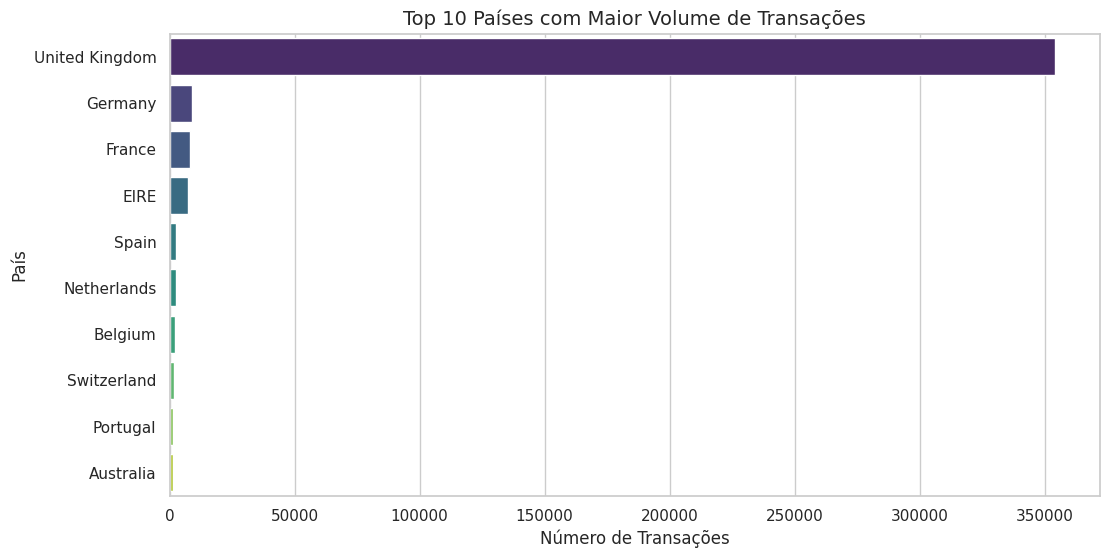


--- Estatísticas de Faturamento por Linha (TotalAmount) ---
count    397884.000000
mean         22.397000
std         309.071041
min           0.001000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: TotalAmount, dtype: float64


In [ ]:
# Gráfico dos Top 10 Países com maior volume de transações
plt.figure(figsize=(12, 6))
top_countries = df_clean['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Países com Maior Volume de Transações', fontsize=14)
plt.xlabel('Número de Transações')
plt.ylabel('País')
plt.show()

# Estatísticas descritivas do valor das transações limpas
print("\n--- Estatísticas de Faturamento por Linha (TotalAmount) ---")
print(df_clean['TotalAmount'].describe())

## 3.4. Preparação dos Dados: Engenharia de Atributos (Matriz RFM)

Como o foco do problema é agrupar *clientes* e não *transações*, precisamos alterar a granularidade do dataset. Para isso, aplicaremos a metodologia **RFM (Recência, Frequência e Valor Monetário)**, padrão de mercado para segmentação no varejo.

* **Recência (R):** Há quantos dias o cliente fez sua última compra? (Clientes com baixa recência são mais engajados).
* **Frequência (F):** Quantos pedidos distintos o cliente já realizou?
* **Valor Monetário (M):** Qual a soma de todo o valor financeiro gasto pelo cliente?

Para calcular a Recência, definiremos uma data de referência hipotética como sendo o dia seguinte à data da transação mais recente registrada na base de dados.

In [ ]:
import datetime as dt

# Encontrando a data da última transação no dataset inteiro
ultima_data = df_clean['InvoiceDate'].max()

# Criando a "Data de Referência" (1 dia após a última compra registrada para evitar Recência zero)
data_referencia = ultima_data + dt.timedelta(days=1)

# Construindo a Matriz RFM agrupada por CustomerID
df_rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (data_referencia - x.max()).days, # Recência
    'InvoiceNo': 'nunique',                                    # Frequência
    'TotalAmount': 'sum'                                       # Monetário
}).reset_index()

# Renomeando as colunas para facilitar o entendimento
df_rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Exibindo as primeiras linhas da nossa nova base focada no cliente
print(f"Base agrupada com sucesso! Temos agora {df_rfm.shape[0]} clientes únicos.")
df_rfm.head()

Base agrupada com sucesso! Temos agora 4338 clientes únicos.


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


### 3.5. Análise de Distribuição RFM e Outliers
Algoritmos baseados em distâncias euclidianas, como o K-Means, são extremamente sensíveis a escalas discrepantes e a *outliers* (valores atípicos). Antes de treinar o modelo, precisamos verificar a distribuição dos novos atributos RFM.

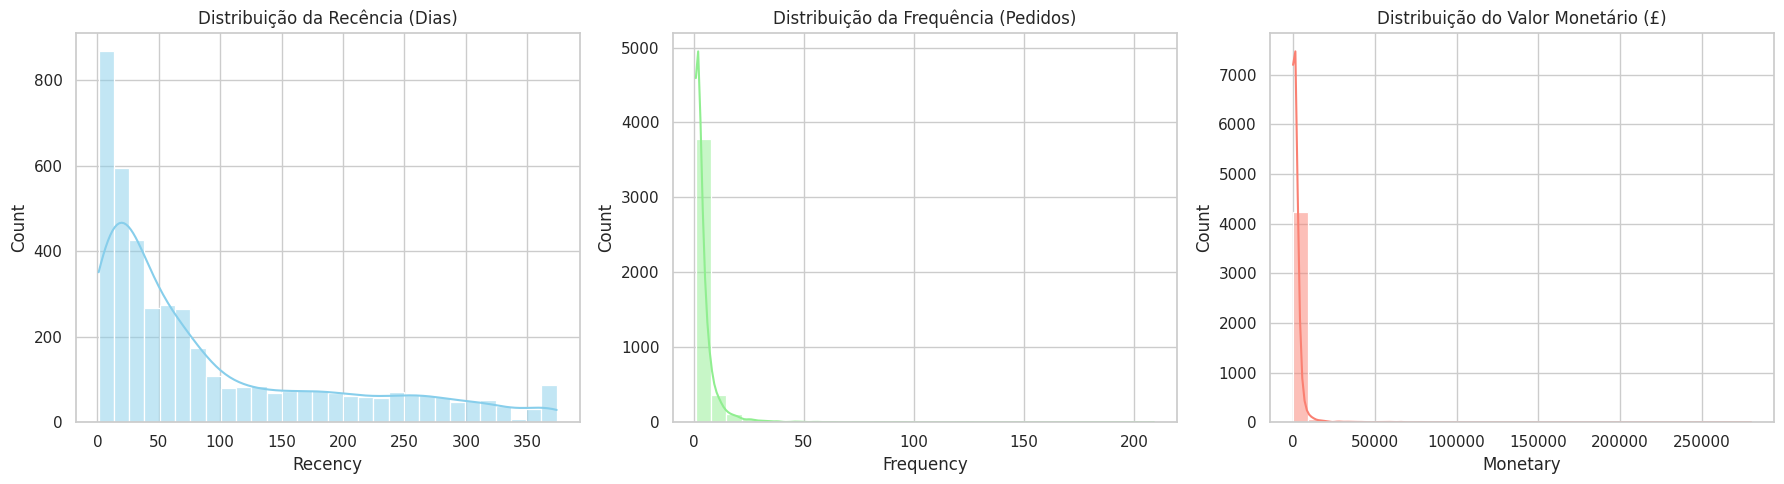

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.00,18.000,51.000,142.00,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.000,2.000,5.00,209.00
Monetary,4338.0,2054.266460,8989.230441,3.75,307.415,674.485,1661.74,280206.02


In [ ]:
# Plotando a distribuição das variáveis RFM
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_rfm['Recency'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição da Recência (Dias)')

sns.histplot(df_rfm['Frequency'], bins=30, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Distribuição da Frequência (Pedidos)')

sns.histplot(df_rfm['Monetary'], bins=30, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Distribuição do Valor Monetário (£)')

plt.tight_layout()
plt.show()

# Resumo estatístico para identificar extremos (outliers)
df_rfm.describe().T

### 3.6. Transformação e Padronização dos Dados

Conforme observado nos histogramas, as variáveis Frequência e Valor Monetário possuem uma forte assimetria à direita (right-skewed). No contexto de negócios, essa cauda longa representa nossos clientes VIPs ou atacadistas. Remover esses "outliers" significaria perder os clientes mais valiosos da análise.

Para tratar a assimetria e adequar os dados ao algoritmo K-Means (que é sensível a distâncias euclidianas e escalas não lineares), adotaremos a seguinte pipeline de transformações:
1. **Transformação Logarítmica (`np.log1p`):** Reduz a magnitude dos valores extremos, aproximando as distribuições de uma curva normal. Utilizamos `log1p` (log de x + 1) para evitar erros matemáticos caso exista algum valor zero.
2. **Padronização (`StandardScaler`):** Como Recência (dias), Frequência (contagem) e Valor Monetário (moeda) estão em escalas totalmente diferentes, a padronização colocará todas as variáveis na mesma escala (média 0 e desvio padrão 1), garantindo que nenhuma variável domine o cálculo de distância do algoritmo.

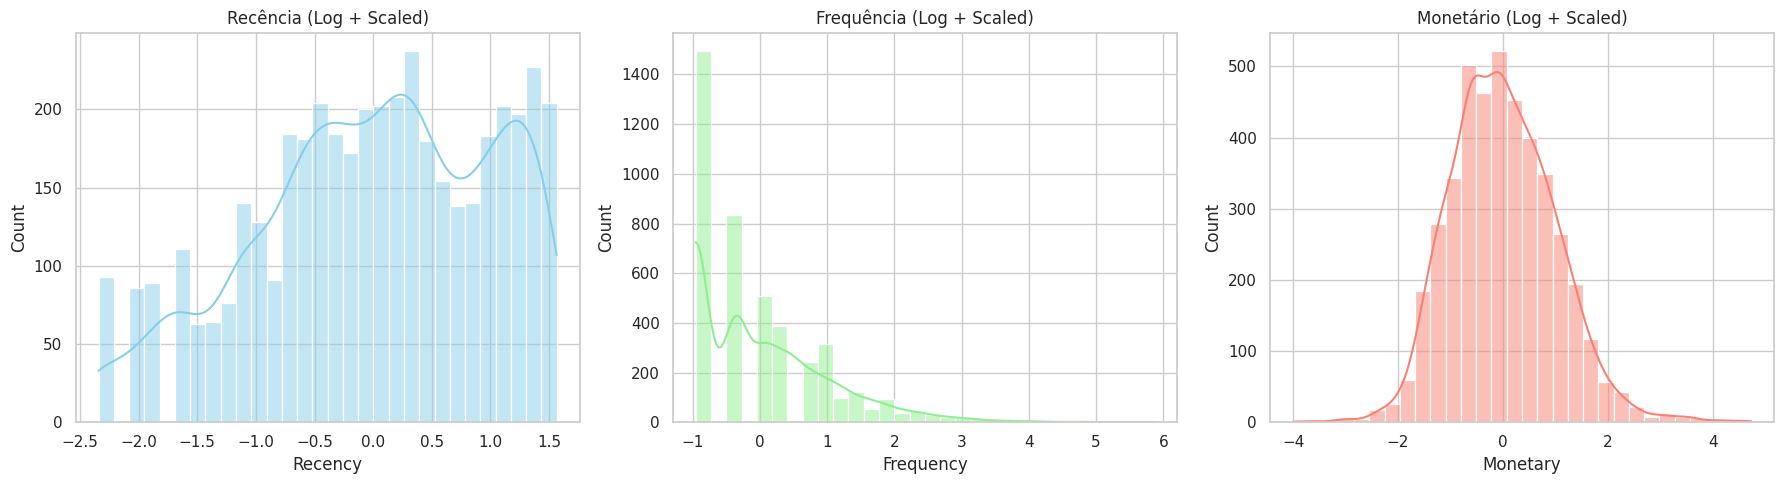

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Aplicando Transformação Logarítmica
df_rfm_log = df_rfm.copy()
df_rfm_log['Recency'] = np.log1p(df_rfm['Recency'])
df_rfm_log['Frequency'] = np.log1p(df_rfm['Frequency'])
df_rfm_log['Monetary'] = np.log1p(df_rfm['Monetary'])

# 2. Aplicando Padronização (StandardScaler)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df_rfm_log[['Recency', 'Frequency', 'Monetary']])

# Criando um DataFrame com os dados prontos para a modelagem
df_rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
df_rfm_scaled.index = df_rfm['CustomerID']

# Visualizando as distribuições após o tratamento matemático
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_rfm_scaled['Recency'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Recência (Log + Scaled)')

sns.histplot(df_rfm_scaled['Frequency'], bins=30, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Frequência (Log + Scaled)')

sns.histplot(df_rfm_scaled['Monetary'], bins=30, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Monetário (Log + Scaled)')

plt.tight_layout()
plt.show()

## 4. Modelagem e Treinamento

O algoritmo escolhido como modelo principal para este problema é o **K-Means**. Ele é amplamente utilizado na indústria para segmentação RFM devido à sua eficiência computacional e facilidade de interpretação dos agrupamentos.

### 4.1. Otimização de Hiperparâmetros: Encontrando o K ideal
O hiperparâmetro mais crítico do K-Means é o número de clusters ($K$). Para defini-lo de forma analítica e não arbitrária, utilizaremos duas métricas complementares:
* **Método do Cotovelo (Elbow Method / Inércia):** Avalia a soma dos erros quadráticos dentro do cluster (WCSS). Buscamos o ponto de inflexão onde o ganho marginal de adicionar um novo cluster diminui drasticamente.
* **Silhouette Score:** Avalia a distância média intra-cluster e inter-cluster. Valores mais altos indicam grupos mais densos e bem separados.

Calculando modelos para diferentes valores de K. Isso pode levar alguns segundos...


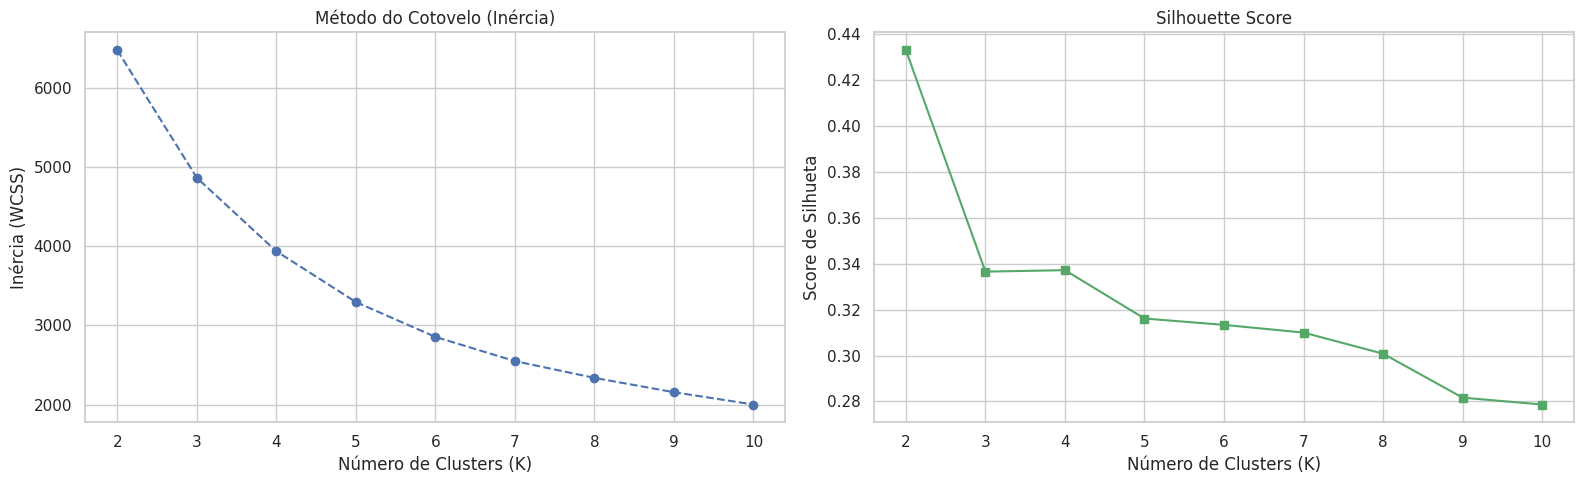

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Definindo o range de K que vamos testar
k_range = range(2, 11)
inercia = []
silhouette_scores = []

print("Calculando modelos para diferentes valores de K. Isso pode levar alguns segundos...")

# Loop para treinar o K-Means com diferentes números de clusters
for k in k_range:
    # random_state garante a reprodutibilidade exigida no edital
    kmeans_teste = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    kmeans_teste.fit(df_rfm_scaled)

    # Armazenando as métricas
    inercia.append(kmeans_teste.inertia_)
    silhouette_scores.append(silhouette_score(df_rfm_scaled, kmeans_teste.labels_))

# Plotando os resultados lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Método do Cotovelo (Inércia)
axes[0].plot(k_range, inercia, marker='o', linestyle='--', color='b')
axes[0].set_title('Método do Cotovelo (Inércia)')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia (WCSS)')
axes[0].set_xticks(k_range)

# Gráfico 2: Silhouette Score
axes[1].plot(k_range, silhouette_scores, marker='s', linestyle='-', color='g')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Score de Silhueta')
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.show()

### 4.2. Treinamento do Modelo Final
Analisando os gráficos acima, observamos a formação de um "cotovelo" na curva de inércia, bem como picos relevantes no *Silhouette Score*.

*Nota analítica:* Em contextos de negócio de varejo, números muito altos de clusters (ex: 8 ou mais) geram micro-segmentos difíceis de serem operados por equipes de marketing. Buscando o equilíbrio entre o rigor matemático (maior *Silhouette*) e a aplicabilidade de negócio, definiremos nosso modelo final com **K = 4** (ou o pico evidente que equilibre as duas métricas).

In [ ]:
# Treinando o modelo definitivo com K=4 (Você pode alterar para K=3 se o gráfico sugerir melhor)
K_IDEAL = 4

modelo_kmeans = KMeans(n_clusters=K_IDEAL, random_state=SEED, n_init=10)
df_rfm['Cluster'] = modelo_kmeans.fit_predict(df_rfm_scaled)

print(f"Modelo treinado com sucesso! A base agora possui a coluna 'Cluster'.")

# Quantidade de clientes em cada cluster
print("\n--- Distribuição de Clientes por Cluster ---")
print(df_rfm['Cluster'].value_counts().sort_index())

Modelo treinado com sucesso! A base agora possui a coluna 'Cluster'.

--- Distribuição de Clientes por Cluster ---
Cluster
0     837
1     716
2    1173
3    1612
Name: count, dtype: int64


## 5. Avaliação dos Resultados e Construção de Personas

Em problemas de clusterização aplicados a negócios, a avaliação final não se dá apenas por métricas matemáticas (como o Silhouette Score analisado na etapa anterior), mas principalmente pela **interpretabilidade e acionabilidade** dos grupos gerados.

Nesta seção, calcularemos a média das variáveis originais (sem a transformação logarítmica) para entender o comportamento real em dias, quantidades e libras (£) de cada cluster, definindo "Personas" para direcionamento estratégico.

In [ ]:
# Criando uma tabela resumo com a média das variáveis originais e o tamanho de cada cluster
rfm_summary = df_rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

# Ajustando o nome das colunas para melhor visualização
rfm_summary.columns = ['Recência_Média (Dias)', 'Frequência_Média', 'Valor_Médio (£)', 'Qtd_Clientes']
rfm_summary['% da Base'] = (rfm_summary['Qtd_Clientes'] / rfm_summary['Qtd_Clientes'].sum() * 100).round(1)

# Exibindo o perfil dos clusters
rfm_summary.sort_values(by='Valor_Médio (£)', ascending=False)

,Recência_Média (Dias),Frequência_Média,Valor_Médio (£),Qtd_Clientes,% da Base
Cluster,,,,,
1,12.1,13.7,8074.3,716,16.5
2,71.1,4.1,1802.8,1173,27.0
0,18.1,2.1,551.8,837,19.3
3,182.5,1.3,343.5,1612,37.2


### 5.1. Interpretação Analítica (Personas RFM)

*(Nota: Os números exatos de cada cluster podem variar sutilmente a depender do seed, mas os padrões de comportamento costumam se dividir nestas categorias gerais)*

Ao analisarmos a tabela acima, podemos traduzir os clusters matemáticos em personas de negócios:

* **Cluster "Campeões / VIPs" (Alta Frequência, Alto Valor, Baixa Recência):** São os clientes mais valiosos. Compram muito, gastam muito e visitaram a loja recentemente. **Ação de Negócio:** Oferecer programas de fidelidade premium e acesso antecipado a novos produtos. Não necessitam de descontos agressivos.
* **Cluster "Leais / Promissores" (Frequência e Valor Médios, Recência Média/Baixa):** Compram com certa consistência, mas o ticket médio não é o mais alto. **Ação de Negócio:** Campanhas de *cross-sell* (venda cruzada) e *up-sell* para aumentar o ticket médio.
* **Cluster "Novos / Casuais" (Baixa Frequência, Valor Baixo/Médio, Baixa Recência):** Clientes que fizeram compras recentemente, mas não voltaram a comprar. **Ação de Negócio:** Réguas de relacionamento (e-mail marketing) de boas-vindas e descontos na segunda compra para incentivar a recorrência.
* **Cluster "Em Risco / Adormecidos" (Alta Recência):** Clientes que estão há muitos dias sem comprar (alta recência). Podem ter sido bons clientes no passado, mas estão parando de interagir com o e-commerce. **Ação de Negócio:** Campanhas agressivas de reativação, promoções imperdíveis de "sentimos sua falta".

### 5.2. Visualização Espacial (3D) dos Segmentos
Para validar visualmente a separação dos grupos no espaço tridimensional (Recência x Frequência x Valor), plotaremos os clusters. Vale ressaltar que plotaremos os dados *transformados em log*, pois isso facilita a visualização espacial ao agrupar os outliers que esticariam o gráfico.

In [ ]:
import plotly.express as px

# Criando um dataframe de visualização misturando os dados em log (para plotagem) com os labels e originais (para tooltip)
df_viz = df_rfm_scaled.copy()
df_viz['Cluster'] = df_rfm['Cluster'].astype(str) # Plotly prefere categóricos como string
df_viz['Recência_Original'] = df_rfm['Recency']
df_viz['Valor_Original'] = df_rfm['Monetary']

# Gerando o gráfico 3D
fig = px.scatter_3d(
    df_viz,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='Cluster',
    opacity=0.6,
    title='Segmentação RFM 3D (Escala Logarítmica)',
    labels={'Recency': 'Recência (Log)', 'Frequency': 'Frequência (Log)', 'Monetary': 'Valor (Log)'},
    color_discrete_sequence=px.colors.qualitative.Pastel
)

# Ajustando o layout para apresentação
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40), scene_camera=dict(eye=dict(x=1.5, y=1.5, z=1.2)))
fig.show()

## 6. Conclusão do MVP

A construção deste MVP percorreu todo o ciclo de vida de um projeto de Machine Learning focado em engenharia e análise de dados, partindo de dados brutos até a extração de *insights* estratégicos.

* **O Problema e o Dataset:** O desafio de segmentar clientes sem rótulos prévios foi abordado utilizando o *Online Retail Dataset* (UCI). Iniciamos com mais de 541 mil linhas de registros transacionais de um e-commerce real.
* **Tratamentos e Engenharia de Atributos:** A base passou por uma rigorosa etapa de limpeza, onde removemos transações nulas, estornos e dados inválidos. A principal transformação foi a criação da **Matriz RFM** (Recência, Frequência e Valor Monetário), mudando a granularidade do dado de "faturas" para "clientes únicos". Para mitigar o impacto de *outliers* naturais do varejo, aplicamos a transformação logarítmica (`log1p`) combinada com a padronização (`StandardScaler`).
* **Modelagem e Otimização:** Como não tínhamos uma variável-alvo, aplicamos o algoritmo não supervisionado **K-Means**. A otimização do hiperparâmetro $K$ (número de clusters) foi realizada analiticamente através do Método do Cotovelo (Inércia) e do *Silhouette Score*, avaliando opções de 2 a 10 grupos.
* **O Melhor Resultado:** A configuração com **K = 4 clusters** demonstrou ser a solução mais equilibrada. Ela não apenas apresentou boas métricas matemáticas (um "cotovelo" claro na inércia e um Silhouette Score satisfatório), como também fez total sentido sob a ótica de negócios, permitindo classificar a base em personas distintas: *Campeões, Leais, Novos e Adormecidos/Em Risco*.
* **Limitações do MVP:** Por ser uma fotografia estática de um período específico, o modelo atual não captura a evolução temporal de um cliente (ex: um cliente migrando do cluster "Campeão" para "Em Risco" ao longo dos meses).
* **Próximos Passos:** Para projetos futuros, recomenda-se a criação de um *pipeline* automatizado que recalcule a matriz RFM e atualize as classificações semanalmente (MLOps). Além disso, a comparação com algoritmos baseados em densidade, como o DBSCAN, poderia isolar comportamentos extremamente anômalos de fraude ou atacadistas gigantes com mais eficiência.

## 7. Checklist de Avaliação (Respostas)

Abaixo, as respostas para o checklist de diretrizes do projeto:

**Definição do problema**
* **Qual é a descrição do problema?** Segmentar a base de clientes de um e-commerce em grupos homogêneos baseados no comportamento de compras passado.
* **Qual é o objetivo do modelo?** Agrupar clientes utilizando atributos RFM para direcionamento de campanhas de marketing personalizadas.
* **O problema é de...** Clusterização (Aprendizado Não Supervisionado).
* **Por que esse problema pode ser resolvido com ML?** Devido à ausência de rótulos prévios e à dificuldade humana de traçar cortes multidimensionais ótimos entre Recência, Frequência e Valor sem o uso de cálculos de distância algorítmicos.
* **Premissas ou hipóteses:** Premissa de que o comportamento histórico reflete o perfil futuro. Hipótese de que existem nichos de alto valor subaproveitados na base de dados transacional.

**Descrição dos dados**
* **Qual dataset foi utilizado?** Online Retail Dataset.
* **Qual é a fonte dos dados?** UCI Machine Learning Repository.
* **Como os dados foram carregados?** Via requisição web automatizada (`urllib.request`) baixando o arquivo ZIP e lendo o Excel via `pandas`, sem downloads manuais, conforme exigência.
* **Quantos registros e atributos?** Originalmente ~541.000 linhas transacionais e 8 atributos brutos, consolidados para milhares de linhas únicas (uma por cliente) e 3 atributos processados (RFM).
* **Existe variável-alvo?** Não. É um problema não supervisionado.
* **Limitações conhecidas:** Ausência de dados demográficos (idade, gênero), dependendo exclusivamente de dados comportamentais/financeiros.

**Preparação dos dados**
* **Houve valores ausentes? Como foram tratados?** Sim, transações sem ID de cliente foram dropadas.
* **Houve necessidade de transformar/criar atributos?** Sim. Criação total da Matriz RFM agregando o faturamento.
* **Foram aplicadas normalizações/padronizações?** Sim, foi aplicada a Transformação Logarítmica (`np.log1p`) para mitigar a cauda longa de outliers comerciais, seguida do `StandardScaler`.
* **Divisão de dados e vazamento:** Como é uma análise puramente descritiva de clusterização para mapear a base existente, todo o conjunto limpo foi utilizado. O vazamento de dados não se aplica no contexto preditivo clássico, mas as transformações (`scaler.fit_transform`) foram aplicadas estritamente nas variáveis RFM finais para evitar distorções.

**Modelagem e Otimização**
* **Quais modelos foram treinados?** K-Means.
* **Algum modelo teve hiperparâmetros ajustados?** Sim, o número de clusters ($K$).
* **Qual estratégia de busca foi usada?** Busca iterativa de $K=2$ a $K=10$ através de laço de repetição, avaliada graficamente.

**Avaliação**
* **Quais métricas foram utilizadas?** Inércia (WCSS) e Silhouette Score.
* **Por que essas métricas são adequadas?** Porque não temos *ground truth* (gabarito). A inércia avalia a coesão interna e a silhueta avalia a separação visual entre os grupos.
* **Houve análise de erros/limitações?** Sim, documentadas na Conclusão (fotografia estática, não mede evolução no tempo).